<a href="https://colab.research.google.com/github/Rajde13/Rajdeep-Deb/blob/main/Phase_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**PHASE 2 — Statistical Analysis & Clustering**

1. Load the Dataset

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
url = "https://raw.githubusercontent.com/salemprakash/EDA/main/Data/Fishing.csv"

df = pd.read_csv(url)

df.head()

,rownames,mode,price,catch,pbeach,ppier,pboat,pcharter,cbeach,cpier,cboat,ccharter,income
0,1,charter,182.930,0.5391,157.930,157.930,157.930,182.930,0.0678,0.0503,0.2601,0.5391,7083.3317
1,2,charter,34.534,0.4671,15.114,15.114,10.534,34.534,0.1049,0.0451,0.1574,0.4671,1249.9998
2,3,boat,24.334,0.2413,161.874,161.874,24.334,59.334,0.5333,0.4522,0.2413,1.0266,3749.9999
3,4,pier,15.134,0.0789,15.134,15.134,55.930,84.930,0.0678,0.0789,0.1643,0.5391,2083.3332
4,5,boat,41.514,0.1082,106.930,106.930,41.514,71.014,0.0678,0.0503,0.1082,0.3240,4583.3320


PART A — 1D Statistical Analysis

1. Mean, Median and Mode

In [3]:
print("Income Mean:", df["income"].mean())
print("Income Median:", df["income"].median())
print("Income Mode:", df["income"].mode()[0])

Income Mean: 4099.337054145516
Income Median: 3749.9999
Income Mode: 2916.6666


2. Variance and Standard Deviation

In [4]:
print("Income Variance:", df["income"].var())
print("Income Standard Deviation:", df["income"].std())

Income Variance: 6061267.032527526
Income Standard Deviation: 2461.9640599585377


3. Five-Number Summary

In [5]:
print(df["income"].describe())

count     1182.000000
mean      4099.337054
std       2461.964060
min        416.666680
25%       2083.333200
50%       3749.999900
75%       5416.666700
max      12499.998000
Name: income, dtype: float64


4. Distribution of Income

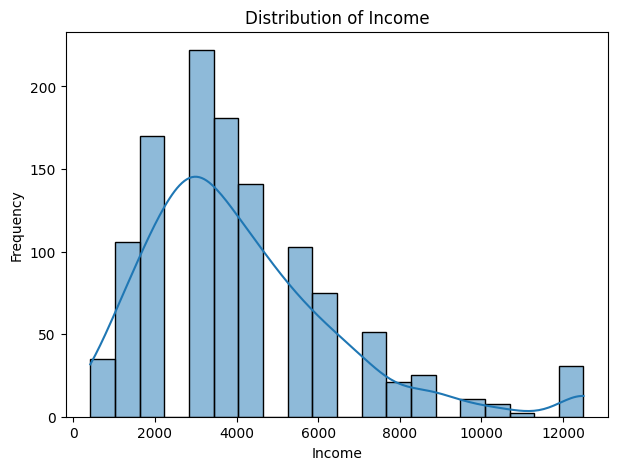

In [6]:
plt.figure(figsize=(7,5))

sns.histplot(df["income"], kde=True)

plt.title("Distribution of Income")
plt.xlabel("Income")
plt.ylabel("Frequency")

plt.show()

5. Boxplot

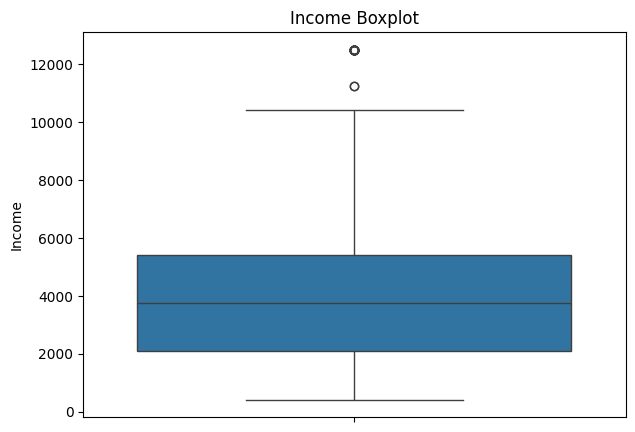

In [7]:
plt.figure(figsize=(7,5))

sns.boxplot(y=df["income"])

plt.title("Income Boxplot")
plt.ylabel("Income")

plt.show()

PART B — 2D Statistical Analysis

1. Covariance

In [8]:
print(df[["price", "catch"]].cov())

             price     catch
price  2897.665640  3.226526
catch     3.226526  0.314268


2. Correlation

In [9]:
print(df[["price", "catch"]].corr())

         price    catch
price  1.00000  0.10692
catch  0.10692  1.00000


3. Scatter Plot

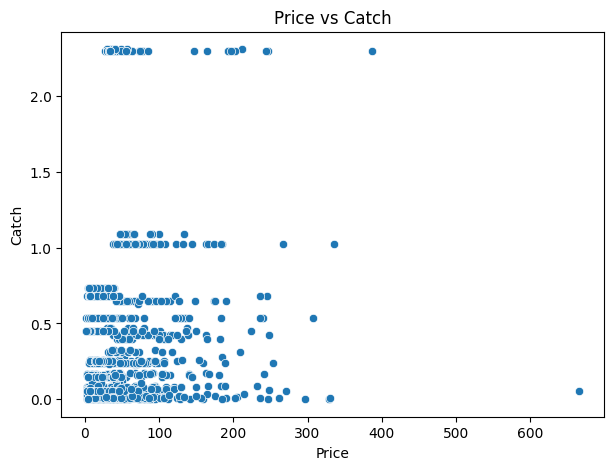

In [10]:
plt.figure(figsize=(7,5))

sns.scatterplot(data=df, x="price", y="catch")

plt.title("Price vs Catch")
plt.xlabel("Price")
plt.ylabel("Catch")

plt.show()

4. Regression Plot

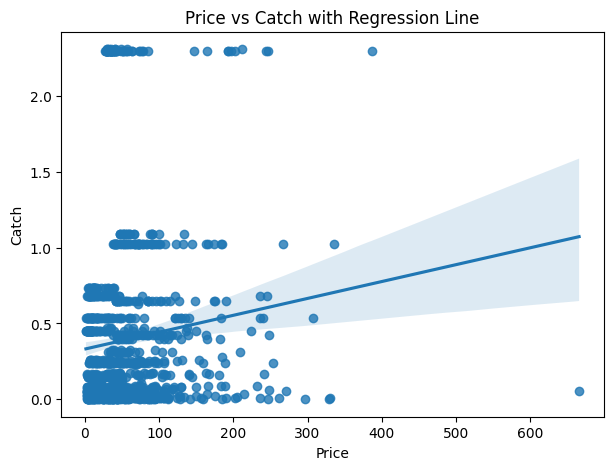

In [11]:
plt.figure(figsize=(7,5))

sns.regplot(data=df, x="price", y="catch")

plt.title("Price vs Catch with Regression Line")
plt.xlabel("Price")
plt.ylabel("Catch")

plt.show()

PART C — 3D Statistical Analysis

1. 3D Scatter Plot

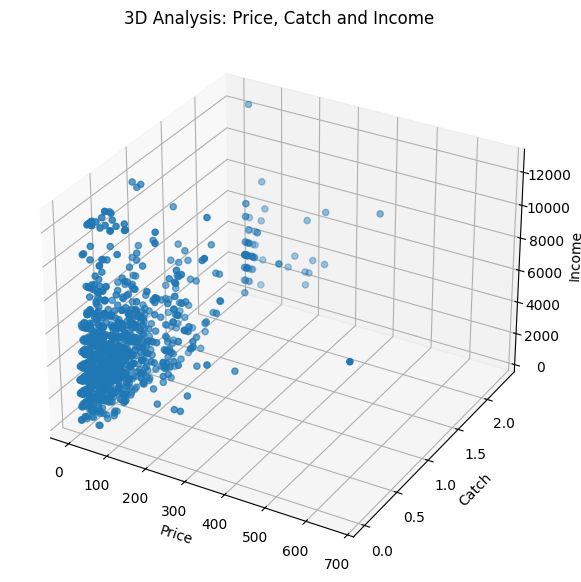

In [12]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(9,7))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    df["price"],
    df["catch"],
    df["income"]
)

ax.set_xlabel("Price")
ax.set_ylabel("Catch")
ax.set_zlabel("Income")

ax.set_title("3D Analysis: Price, Catch and Income")

plt.show()

2. 3D Scatter with Mode

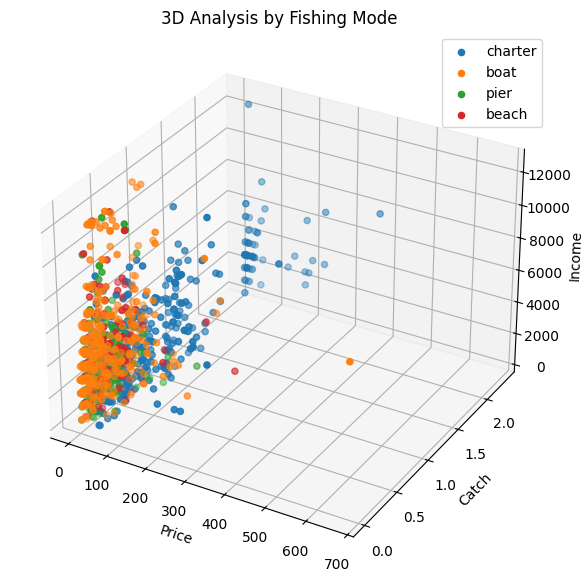

In [13]:
fig = plt.figure(figsize=(9,7))

ax = fig.add_subplot(111, projection="3d")

modes = df["mode"].unique()

for mode in modes:
    subset = df[df["mode"] == mode]

    ax.scatter(
        subset["price"],
        subset["catch"],
        subset["income"],
        label=mode
    )

ax.set_xlabel("Price")
ax.set_ylabel("Catch")
ax.set_zlabel("Income")

ax.set_title("3D Analysis by Fishing Mode")

ax.legend()

plt.show()

PART D — K-MEANS CLUSTERING

Step 1 — Select Features

In [14]:
X = df[["price", "catch", "income"]]

Step 2 — Standardize

In [15]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

3. Find Optimal K Using Elbow Method

In [16]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

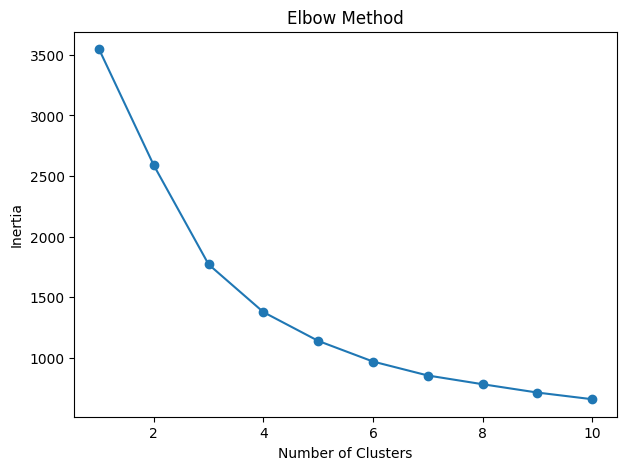

In [17]:
plt.figure(figsize=(7,5))

plt.plot(range(1,11), inertia, marker="o")

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

4. Apply K-Means

In [18]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["KMeans_Cluster"] = kmeans.fit_predict(X_scaled)

In [19]:
df[["price", "catch", "income", "KMeans_Cluster"]].head()

,price,catch,income,KMeans_Cluster
0,182.930,0.5391,7083.3317,2
1,34.534,0.4671,1249.9998,0
2,24.334,0.2413,3749.9999,0
3,15.134,0.0789,2083.3332,0
4,41.514,0.1082,4583.3320,0


 5. Visualize K-Means Clusters

2D visualization

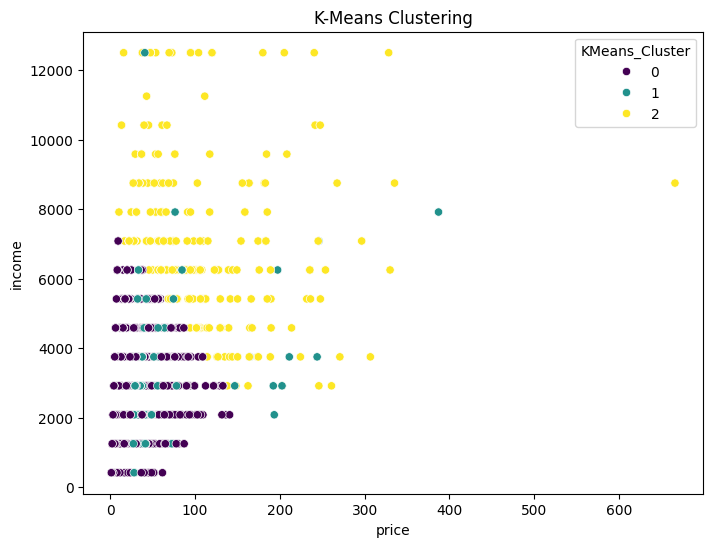

In [20]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="price",
    y="income",
    hue="KMeans_Cluster",
    palette="viridis"
)

plt.title("K-Means Clustering")
plt.show()

6. 3D K-Means Visualization

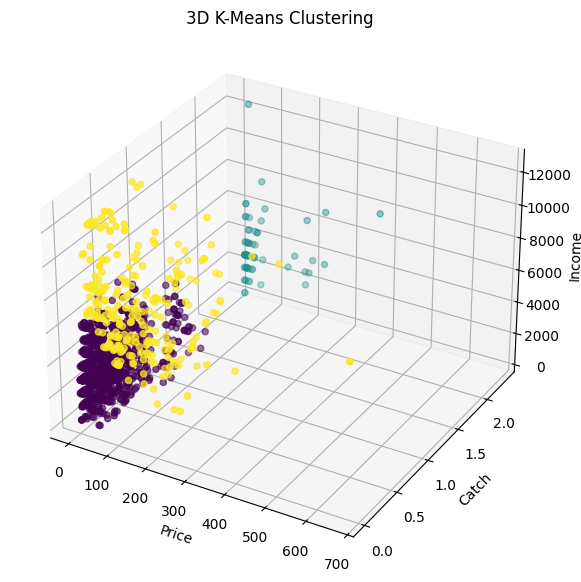

In [21]:
fig = plt.figure(figsize=(9,7))

ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    df["price"],
    df["catch"],
    df["income"],
    c=df["KMeans_Cluster"],
    cmap="viridis"
)

ax.set_xlabel("Price")
ax.set_ylabel("Catch")
ax.set_zlabel("Income")

ax.set_title("3D K-Means Clustering")

plt.show()

PART E — HIERARCHICAL CLUSTERING

1. Create Dendrogram

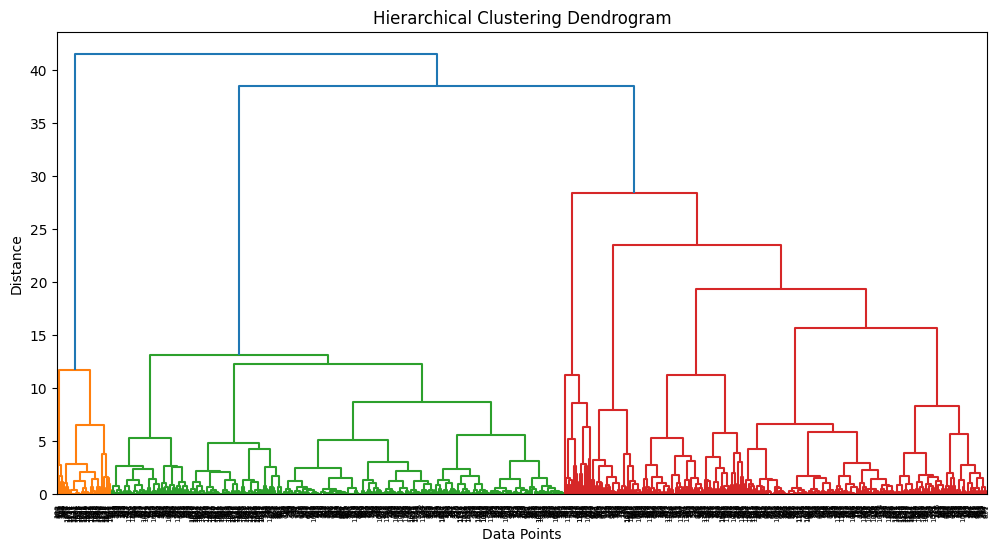

In [22]:
linked = linkage(X_scaled, method="ward")

plt.figure(figsize=(12,6))

dendrogram(linked)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")

plt.show()

2. Apply Hierarchical Clustering

In [23]:
from sklearn.cluster import AgglomerativeClustering

hierarchical = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

df["Hierarchical_Cluster"] = hierarchical.fit_predict(X_scaled)

3. Display Results

In [24]:
df[[
    "price",
    "catch",
    "income",
    "KMeans_Cluster",
    "Hierarchical_Cluster"
]].head(10)

,price,catch,income,KMeans_Cluster,Hierarchical_Cluster
0,182.930,0.5391,7083.3317,2,0
1,34.534,0.4671,1249.9998,0,2
2,24.334,0.2413,3749.9999,0,2
3,15.134,0.0789,2083.3332,0,2
4,41.514,0.1082,4583.3320,0,0
5,63.934,0.3975,4583.3320,0,0
6,51.934,0.0678,8750.0010,2,0
7,56.714,0.0209,2083.3332,0,2
8,34.914,0.0233,3749.9999,0,2
9,28.314,0.0233,2916.6666,0,2


4. Visualize Hierarchical Clusters

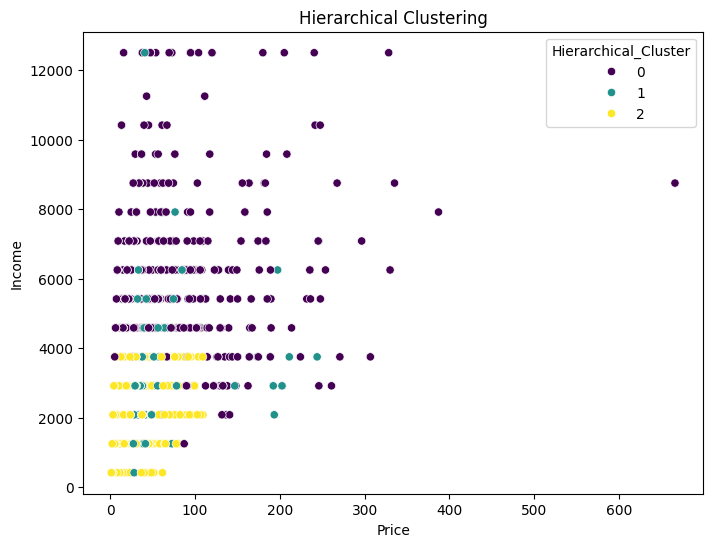

In [25]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="price",
    y="income",
    hue="Hierarchical_Cluster",
    palette="viridis"
)

plt.title("Hierarchical Clustering")
plt.xlabel("Price")
plt.ylabel("Income")

plt.show()

PART F — Compare the Clustering Results

K-Means

In [26]:
print("K-Means Cluster Counts:")

print(df["KMeans_Cluster"].value_counts())

K-Means Cluster Counts:
KMeans_Cluster
0    847
2    265
1     70
Name: count, dtype: int64


Hierarchical

In [27]:
print("Hierarchical Cluster Counts:")

print(df["Hierarchical_Cluster"].value_counts())

Hierarchical Cluster Counts:
Hierarchical_Cluster
2    576
0    537
1     69
Name: count, dtype: int64


PART G — Cluster Summary

In [28]:
cluster_summary = df.groupby("KMeans_Cluster")[
    ["price", "catch", "income"]
].mean()

cluster_summary

,price,catch,income
KMeans_Cluster,,,
0,34.794102,0.269544,3152.793959
1,66.946200,2.302519,3494.047462
2,103.411532,0.266993,7284.590913


In [29]:
hierarchical_summary = df.groupby("Hierarchical_Cluster")[
    ["price", "catch", "income"]
].mean()

hierarchical_summary

,price,catch,income
Hierarchical_Cluster,,,
0,72.652190,0.329097,5959.807210
1,62.304725,2.302535,3429.951537
2,31.679934,0.216377,2445.023038


### Conclusion

In Phase 2, 1D, 2D, and 3D statistical analyses were performed to understand the distribution and relationships between the variables in the dataset. K-Means and Hierarchical Clustering were then applied to group similar data points based on price, catch, and income. The visualizations and clustering results helped identify patterns and similarities within the dataset.
